# Evaluación del clasificador de intenciones de tarjetas

**Pregunta.** ¿El clasificador entrenado enruta mejor que las reglas de palabras clave, en español y portugués, y con qué umbral de confianza puede actuar sin preguntar?

Mapa: 1 plan del experimento, 2 configuración, 3 datos, 4 validación cruzada contra la línea base, 5 resultados por clase, 6 calibración, 7 umbral, 8 conjunto de prueba independiente, 9 errores, 10 latencia, 11 conclusiones.

Toda la lógica vive en `src/factored_bck/intent/` con pruebas; este notebook solo llama, tabula y grafica.

## 1. Plan del experimento

| Punto | Decisión |
| --- | --- |
| Datos | `ml/datasets/intent_train_v1.jsonl`: 280 casos sintéticos del equipo, 10 intenciones x 2 idiomas x 14. Ninguno viene del organizador: sus transcripciones tienen solo 42 textos de cliente distintos en 171,321 filas. |
| Etiquetas | Una etiqueta por caso, taxonomía `card-routing-v1` del ETL. Escritas junto con el texto, sin doble etiquetado. |
| Partición | Validación cruzada de 5 particiones estratificada y agrupada por familia (`StratifiedGroupKFold`). Cada caso se predice con un modelo que no vio su familia. |
| Fugas | Sin textos duplicados tras normalizar (prueba automática). El portugués se escribió aparte, no como traducción. |
| Línea base | Reglas de palabras clave (`baseline.py`), escritas antes de ver resultados. |
| Métricas | Macro F1 como métrica principal, exactitud, recall por clase, intervalos bootstrap del 95%, prueba de McNemar, ECE. |
| Prueba independiente | Los 72 casos borrador del ETL (es/pt), de otro autor. Sección 8; corre solo si el archivo está disponible localmente. |

**Limitación central.** La validación cruzada mide el rendimiento sobre textos del mismo autor que escribió los datos de entrenamiento y las palabras clave. Es una estimación optimista; la sección 8 es la evidencia que cuenta.

In [1]:
import os
import statistics
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

from factored_bck.intent.baseline import predict_keyword
from factored_bck.intent.datasets import TRAIN_PATH, load_cases, overlap
from factored_bck.intent.metrics import (
    accuracy, bootstrap_interval, choose_threshold, coverage_curve,
    expected_calibration_error, gold_primary, macro_f1, mcnemar_p_value, per_class,
)
from factored_bck.intent.model import IntentModel
from factored_bck.intent.taxonomy import LABELS
from factored_bck.intent.training import out_of_fold

GREEN, LEAF, MUTED, EDGE = "#0E4D45", "#3F8A26", "#7F8F8B", "#D4E2D6"
TARGET_ACCURACY = 0.90
HELDOUT_PATH = Path(os.environ.get(
    "INTENT_HELDOUT_PATH",
    "../../FactoredAI_base/data/fixtures/ml-handoff-v1/intent_cases.jsonl",
))
model = IntentModel.load()
model.metadata

{'c': 30.0,
 'c_grid_out_of_fold_macro_f1': {'0.3': 0.5922,
  '1.0': 0.6504,
  '10.0': 0.7293,
  '100.0': 0.7387,
  '3.0': 0.7236,
  '30.0': 0.74,
  '300.0': 0.7324},
 'model_version': 'intent-tfidf-lr-v1',
 'scikit_learn': '1.9.1',
 'seed': 20261004,
 'taxonomy': 'card-routing-v1@0.1.0-draft',
 'training_cases': 280,
 'training_file': 'intent_train_v1.jsonl',
 'training_sha256': '9e86f60e770b7686ab2bb732fd141a50810c5bb9bf5ef2418f14a0056eefe8e6'}

## 3. Datos de entrenamiento

In [2]:
cases = load_cases(TRAIN_PATH)
counts = Counter((case.labels[0], case.language) for case in cases)
print(f"{'intención':<30}{'es':>4}{'pt':>4}")
for label in LABELS:
    print(f"{label:<30}{counts[(label, 'es')]:>4}{counts[(label, 'pt')]:>4}")
print("total", len(cases))

intención                       es  pt
block_lost_stolen               14  14
pause_card                      14  14
reactivate_card                 14  14
activate_card                   14  14
request_replacement             14  14
query_card_status               14  14
query_balance_limit             14  14
query_movements                 14  14
register_unrecognized_charge    14  14
unsupported_unclear             14  14
total 280


## 4. Validación cruzada: modelo contra línea base

Mismos 280 casos para ambos sistemas. El modelo usa el `C` elegido en `ml/train_intent.py`.

In [3]:
gold = [case.labels[0] for case in cases]
probabilities = out_of_fold(cases, c=model.metadata["c"])
model_pred = [max(p, key=p.get) for p in probabilities]
base_pred = [predict_keyword(case.text) for case in cases]

def summary(name, gold, pred):
    acc_ci = bootstrap_interval(accuracy, gold, pred, seed=1)
    f1_ci = bootstrap_interval(lambda g, p: macro_f1(g, p, LABELS), gold, pred, seed=1)
    print(f"{name:<12} n={len(gold):<4} exactitud {accuracy(gold, pred):.3f} "
          f"[{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]  macro F1 {macro_f1(gold, pred, LABELS):.3f} "
          f"[{f1_ci[0]:.3f}, {f1_ci[1]:.3f}]")

for language in ("all", "es", "pt"):
    idx = [i for i, case in enumerate(cases) if language in ("all", case.language)]
    print(f"-- {language}")
    summary("línea base", [gold[i] for i in idx], [base_pred[i] for i in idx])
    summary("modelo", [gold[i] for i in idx], [model_pred[i] for i in idx])

model_ok = [g == p for g, p in zip(gold, model_pred)]
base_ok = [g == p for g, p in zip(gold, base_pred)]
print("McNemar p =", round(mcnemar_p_value(model_ok, base_ok), 6),
      "| solo el modelo acierta:", sum(m and not b for m, b in zip(model_ok, base_ok)),
      "| solo la línea base acierta:", sum(b and not m for m, b in zip(model_ok, base_ok)))

-- all


línea base   n=280  exactitud 0.589 [0.529, 0.643]  macro F1 0.612 [0.552, 0.661]


modelo       n=280  exactitud 0.746 [0.693, 0.796]  macro F1 0.740 [0.683, 0.786]
-- es


línea base   n=140  exactitud 0.586 [0.507, 0.664]  macro F1 0.609 [0.517, 0.678]


modelo       n=140  exactitud 0.757 [0.686, 0.829]  macro F1 0.752 [0.672, 0.814]
-- pt


línea base   n=140  exactitud 0.593 [0.514, 0.671]  macro F1 0.614 [0.525, 0.682]


modelo       n=140  exactitud 0.736 [0.657, 0.807]  macro F1 0.728 [0.643, 0.790]
McNemar p = 1.6e-05 | solo el modelo acierta: 73 | solo la línea base acierta: 29


## 5. Resultados por clase (modelo, validación cruzada)

intención                      precisión  recall  recall base
block_lost_stolen                   0.85    0.82         0.71
pause_card                          0.64    0.64         0.71
reactivate_card                     0.58    0.54         0.43
activate_card                       0.65    0.86         0.79
request_replacement                 0.69    0.64         0.36
query_card_status                   0.77    0.71         0.18
query_balance_limit                 0.84    0.93         0.64
query_movements                     0.82    0.96         0.57
register_unrecognized_charge        0.83    0.89         0.61
unsupported_unclear                 0.81    0.46         0.89


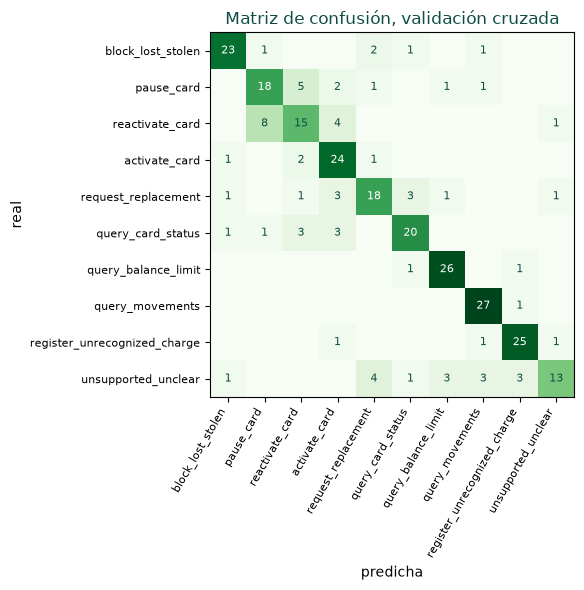

In [4]:
scores = per_class(gold, model_pred, LABELS)
base_scores = per_class(gold, base_pred, LABELS)
print(f"{'intención':<30}{'precisión':>10}{'recall':>8}{'recall base':>13}")
for label in LABELS:
    s = scores[label]
    print(f"{label:<30}{s['precision']:>10.2f}{s['recall']:>8.2f}{base_scores[label]['recall']:>13.2f}")

matrix = [[sum(g == a and p == b for g, p in zip(gold, model_pred)) for b in LABELS] for a in LABELS]
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(matrix, cmap="Greens")
ax.set_xticks(range(len(LABELS)), LABELS, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(LABELS)), LABELS, fontsize=8)
for i, row in enumerate(matrix):
    for j, v in enumerate(row):
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=8, color="white" if v > 15 else GREEN)
ax.set_xlabel("predicha")
ax.set_ylabel("real")
ax.set_title("Matriz de confusión, validación cruzada", color=GREEN)
plt.tight_layout()

## 6. Calibración

Si el modelo dice 80% de confianza, ¿acierta cerca del 80% de las veces? Importa porque el adaptador decide con un umbral sobre esa confianza.

ECE = 0.156


Text(0.5, 1.0, 'Diagrama de confiabilidad')

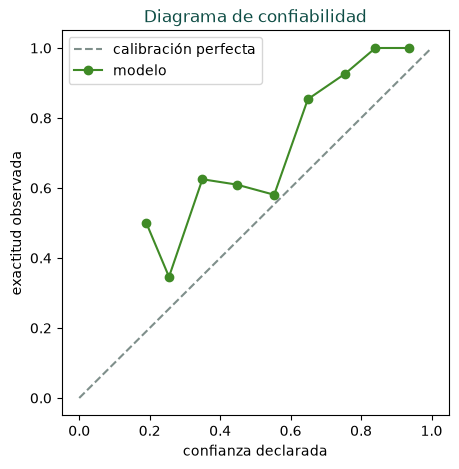

In [5]:
confidence = [max(p.values()) for p in probabilities]
print("ECE =", round(expected_calibration_error(confidence, model_ok), 3))
bins = [i / 10 for i in range(11)]
xs, ys = [], []
for low, high in zip(bins, bins[1:]):
    members = [i for i, c in enumerate(confidence) if low <= c < high or (high == 1 and c == 1)]
    if members:
        xs.append(statistics.mean(confidence[i] for i in members))
        ys.append(statistics.mean(model_ok[i] for i in members))
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", label="calibración perfecta")
ax.plot(xs, ys, marker="o", color=LEAF, label="modelo")
ax.set_xlabel("confianza declarada")
ax.set_ylabel("exactitud observada")
ax.legend()
ax.set_title("Diagrama de confiabilidad", color=GREEN)

## 7. Umbral de confianza

Debajo del umbral el adaptador pide una aclaración en vez de actuar. Elegimos el umbral más bajo cuya exactitud sobre los casos automatizados llega a la meta, para automatizar lo más posible sin bajar de ella. Las acciones que modifican la tarjeta además requieren la confirmación del servidor.

umbral elegido: 0.6
{'threshold': 0.3, 'coverage': 0.9, 'accuracy': 0.7896825396825397, 'automated': 252}
{'threshold': 0.4, 'coverage': 0.7571428571428571, 'accuracy': 0.8207547169811321, 'automated': 212}
{'threshold': 0.5, 'coverage': 0.6107142857142858, 'accuracy': 0.8713450292397661, 'automated': 171}
{'threshold': 0.6, 'coverage': 0.5, 'accuracy': 0.9357142857142857, 'automated': 140}
{'threshold': 0.7, 'coverage': 0.3535714285714286, 'accuracy': 0.9696969696969697, 'automated': 99}


Text(0.5, 1.0, 'Cobertura contra exactitud')

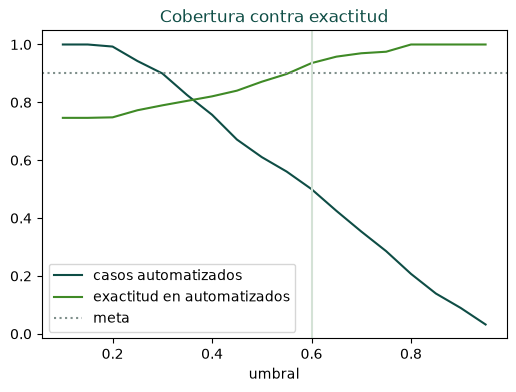

In [6]:
curve = coverage_curve(confidence, model_ok)
threshold = choose_threshold(confidence, model_ok, TARGET_ACCURACY)
print("umbral elegido:", threshold)
for point in curve:
    if point["threshold"] in (0.3, 0.4, 0.5, 0.6, 0.7, threshold):
        print(point)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([p["threshold"] for p in curve], [p["coverage"] for p in curve], color=GREEN, label="casos automatizados")
ax.plot([p["threshold"] for p in curve], [p["accuracy"] for p in curve], color=LEAF, label="exactitud en automatizados")
ax.axhline(TARGET_ACCURACY, color=MUTED, linestyle=":", label="meta")
ax.axvline(threshold, color=EDGE)
ax.set_xlabel("umbral")
ax.legend()
ax.set_title("Cobertura contra exactitud", color=GREEN)

## 8. Conjunto de prueba independiente (72 borradores del ETL)

Casos escritos por otro autor; el modelo nunca los vio. Si el archivo no está en `INTENT_HELDOUT_PATH`, la celda lo dice y no reporta nada.

In [7]:
if HELDOUT_PATH.exists():
    heldout = load_cases(HELDOUT_PATH)
    print("solapamiento con entrenamiento:", overlap(cases, heldout))
    h_gold = [gold_primary(case.labels) for case in heldout]
    h_prob = [model.predict_proba(case.text) for case in heldout]
    h_model = [max(p, key=p.get) for p in h_prob]
    h_base = [predict_keyword(case.text) for case in heldout]
    # A prediction counts as right when it is any of the gold labels (multi label cases).
    h_model_ok = [p in case.labels for p, case in zip(h_model, heldout)]
    h_base_ok = [p in case.labels for p, case in zip(h_base, heldout)]
    for language in ("all", "es", "pt"):
        idx = [i for i, case in enumerate(heldout) if language in ("all", case.language)]
        print(f"-- {language}")
        summary("línea base", [h_gold[i] for i in idx], [h_base[i] for i in idx])
        summary("modelo", [h_gold[i] for i in idx], [h_model[i] for i in idx])
    print("acierto multietiqueta: modelo", round(sum(h_model_ok) / len(heldout), 3),
          "línea base", round(sum(h_base_ok) / len(heldout), 3))
    print("McNemar p =", round(mcnemar_p_value(h_model_ok, h_base_ok), 6))
    h_conf = [max(p.values()) for p in h_prob]
    automated = [ok for c, ok in zip(h_conf, h_model_ok) if c >= threshold]
    print(f"con umbral {threshold}: automatiza {len(automated)}/{len(heldout)}, "
          f"exactitud {sum(automated) / max(len(automated), 1):.3f}")
else:
    print("PENDIENTE: no existe", HELDOUT_PATH)

PENDIENTE: no existe ../../FactoredAI_base/data/fixtures/ml-handoff-v1/intent_cases.jsonl


## 9. Errores más confiados (validación cruzada)

In [8]:
mistakes = sorted(
    (i for i, ok in enumerate(model_ok) if not ok), key=lambda i: -confidence[i]
)[:10]
for i in mistakes:
    print(f"{confidence[i]:.2f}  real={gold[i]:<28} pred={model_pred[i]:<28} {cases[i].text}")

0.78  real=pause_card                   pred=activate_card                Desativa o cartão por enquanto, depois eu ativo de novo
0.77  real=query_card_status            pred=activate_card                ¿Ya se activó la tarjeta nueva?
0.71  real=query_card_status            pred=activate_card                O cartão novo já foi ativado?
0.68  real=pause_card                   pred=activate_card                Desactiva la tarjeta por ahora, la vuelvo a activar después
0.67  real=reactivate_card              pred=pause_card                   Desfaçam a pausa temporária do meu cartão de débito
0.65  real=pause_card                   pred=reactivate_card              quero colocar meu cartão em pausa
0.64  real=reactivate_card              pred=pause_card                   La tarjeta está en pausa y la necesito usar hoy
0.63  real=reactivate_card              pred=pause_card                   Quero tirar a suspensão temporária do cartão
0.63  real=reactivate_card              pred=pause_

## 10. Latencia de inferencia (proceso local, sin red)

In [9]:
timings = []
for case in cases:
    start = time.perf_counter()
    model.predict_proba(case.text)
    timings.append((time.perf_counter() - start) * 1000)
timings.sort()
print(f"n={len(timings)}  p50={timings[len(timings) // 2]:.2f} ms  p95={timings[int(0.95 * len(timings))]:.2f} ms")

n=280  p50=0.06 ms  p95=0.08 ms


## 11. Conclusiones

Resultados de validación cruzada sobre 280 casos sintéticos del equipo (evaluación fuera de línea, no medición en producción):

1. **El modelo supera a la línea base.** Macro F1 0.740 [0.683, 0.786] contra 0.612 [0.552, 0.661]. McNemar p = 0.00002: en los casos donde discrepan, el modelo acierta 73 y la línea base 29. Español y portugués rinden parecido (0.752 y 0.728).
2. **Punto débil: la dirección de la acción.** Pausar, reactivar y activar se confunden ("desactiva... la vuelvo a activar"). Los n-gramas de caracteres ven la raíz "activ" pero no la negación ni el sentido.
3. **Los pedidos poco claros son el otro punto débil.** El recall de `unsupported_unclear` es 0.46 (línea base 0.89, porque es su opción por defecto). El modelo tiende a forzar un mensaje vago hacia alguna intención; el umbral lo compensa.
4. **Calibración pobre, en dirección conservadora.** ECE 0.156: el modelo es subconfiado (con confianza de 0.6 o más acierta 93.6%). Por eso el umbral se eligió con la exactitud observada y no con la confianza declarada.
5. **Umbral 0.6.** Automatiza el 50% de los mensajes con 93.6% de exactitud; el resto recibe una pregunta de aclaración. Es la decisión que usa el adaptador.
6. **Latencia** de 0.06 ms p50 por predicción, sin red ni dependencias nuevas en la API.

**Limitaciones.** Los datos de entrenamiento, las palabras clave de la línea base y esta validación tienen el mismo autor, así que estos números son optimistas. La evidencia que cuenta es la sección 8 con los 72 casos independientes del ETL, pendiente de recibir el archivo. Sin doble etiquetado no hay medida de acuerdo entre anotadores. Los datos son sintéticos y no representan clientes reales.

**Resumen simple.** El clasificador entiende mejor que unas reglas de palabras qué quiere el cliente, en los dos idiomas. Cuando está seguro casi siempre acierta, y cuando no lo está pregunta en vez de adivinar. Todavía falta probarlo con casos escritos por otra persona.